# KNN classifier
> drug_class.csv

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv('drug_class.csv')
df.head()

,Age,Gender,BloodPressure,Cholestrol,Na_to_K,Class
0,23,M,LOW,HIGH,7.301033,drugC
1,69,M,LOW,HIGH,15.478000,drugY
2,74,M,HIGH,HIGH,9.516477,drugB
3,60,M,HIGH,NORMAL,8.742942,drugB
4,39,F,NORMAL,NORMAL,9.715872,drugX


In [3]:
# encoding 
class_encoder = LabelEncoder()
gender_encoder = LabelEncoder()
bp_encoder = LabelEncoder()
chol_encoder = LabelEncoder()


df['Gender'] = gender_encoder.fit_transform(df['Gender'])
df['BloodPressure'] = bp_encoder.fit_transform(df['BloodPressure'])
df['Class'] = class_encoder.fit_transform(df['Class'])
df['Cholestrol'] = chol_encoder.fit_transform(df['Cholestrol'])

In [4]:
# features and target
x = df.iloc[:,0:-1]
y = df.iloc[:,-1]

# data split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

In [5]:
# standardization
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

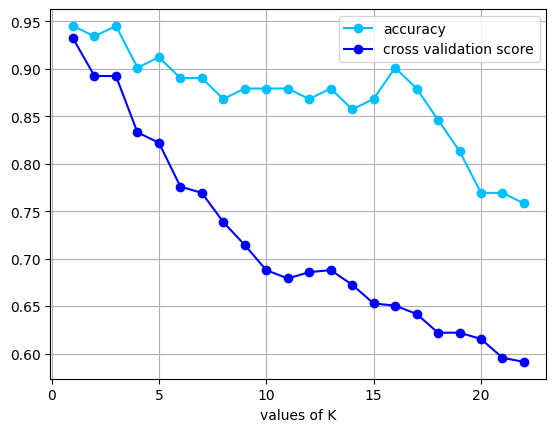

In [6]:
# different values of k
accuracy_score_list = []
cross_val_score_list = []

for i in range(1, 23):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    accuracy_score_list.append(accuracy_score(y_test, y_pred))
    cross_val_score_list.append(cross_val_score(knn, x, y, cv=5).mean())


plt.plot(range(1,23), accuracy_score_list, color = 'deepskyblue', marker = 'o', label = 'accuracy')
plt.plot(range(1,23), cross_val_score_list, color = 'blue', marker = 'o', label = 'cross validation score')
plt.xlabel('values of K')
plt.legend()
plt.grid(True)
plt.show()

> best value of k = 1

ACCURACY:  0.945054945054945




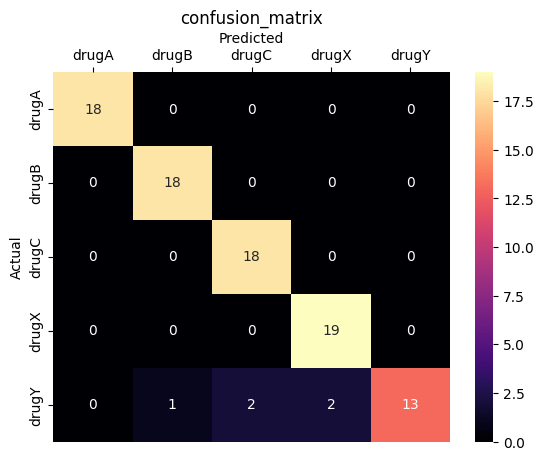

In [7]:
# model train
KNN = KNeighborsClassifier(n_neighbors=1)
KNN.fit(x_train, y_train)
y_Pred = KNN.predict(x_test)

print('ACCURACY: ',accuracy_score(y_test, y_Pred))
print('\n')
sns.heatmap(confusion_matrix(y_test, y_Pred), annot = True, xticklabels=class_encoder.classes_, yticklabels=class_encoder.classes_, cmap = 'magma')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.gca().xaxis.set_label_position("top")
plt.gca().xaxis.tick_top()
plt.title('confusion_matrix')
plt.show()

In [8]:
age = int(input("Enter Age: "))
gender = input("Enter Gender (F/M): ").upper()
bp = input("Enter Blood Pressure (HIGH/LOW/NORMAL): ").upper()
chol = input("Enter Cholesterol (HIGH/NORMAL): ").upper()
na_to_k = float(input("Enter Na_to_K: "))

gender = gender_encoder.transform([gender])[0]
bp = bp_encoder.transform([bp])[0]
chol = chol_encoder.transform([chol])[0]

user = np.array([[age, gender, bp, chol, na_to_k]])
user = scaler.transform(user)

prediction = KNN.predict(user)
drug = class_encoder.inverse_transform(prediction)

print("Predicted Drug:", drug[0])

Predicted Drug: drugY


/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
